# ***MOVIE SENTIMENT ANALYSIS***

In [ ]:
pip install contractions

## **1. IMPORTING LIBRARIES**

In [ ]:
# Basic data manipulation libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
# NLP
from nltk import pos_tag
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
import nltk
import re
import contractions
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [ ]:

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay


## **2. LOADING THE DATASET**


In [ ]:
data = pd.read_csv("/content/IMDB Dataset.csv", engine="python", on_bad_lines="skip")

### **2.1 DATA EXPLORATION**

In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
data.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
data.shape

(50000, 2)

In [ ]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [ ]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
data.iloc[0].review

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [ ]:
data.isna().sum()

,0
review,0
sentiment,0


In [ ]:
data.isnull().sum()

,0
review,0
sentiment,0


In [ ]:
data.duplicated().sum()

np.int64(418)

In [ ]:
data.nunique()

,0
review,49582
sentiment,2


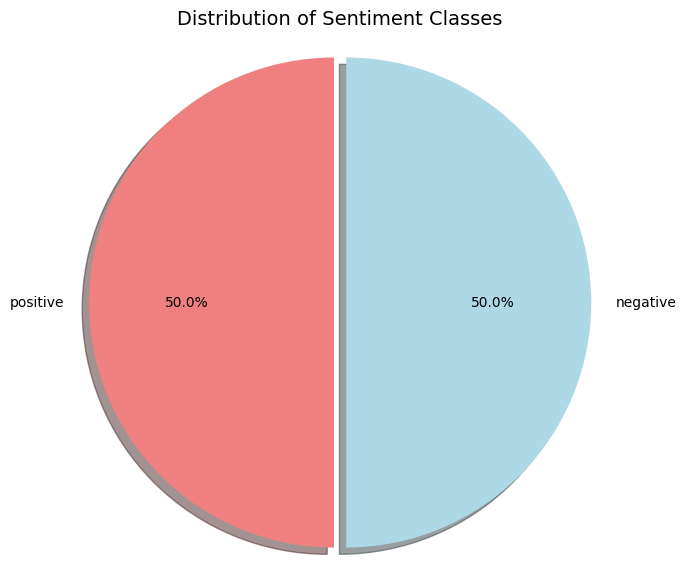

In [ ]:










# Calculate sentiment distribution
sentiment_counts = data['sentiment'].value_counts()
sentiment_labels = sentiment_counts.index
sentiment_sizes = sentiment_counts.values

# Plot sentiment distribution as a pie chart
plt.figure(figsize=(7, 7))
plt.pie(sentiment_sizes, labels=sentiment_labels, autopct='%1.1f%%', startangle=90, colors=['lightcoral', 'lightblue'], explode=(0.05, 0), shadow=True)
plt.title('Distribution of Sentiment Classes', fontsize=14)
plt.axis('equal')
plt.show()






### **2.2 EXPLORATORY DATA ANALYSIS**

#### **2.2.1 review_length**

In [ ]:
# Calculate the length of the reviews and store it in a new column
data['review_length'] = data['review'].apply(lambda x: len(x.split()))

data.head(5)

,review,sentiment,review_length
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230



#### **2.2.2 review_length_binned**

In [ ]:
# View unique values in the 'review_length' column
unique_lengths = data['review_length'].unique()
print("Unique Review Lengths:")
print(unique_lengths)

# Defining binning boundaries
bins = [0, 100, 500, 1000, 1500, float('inf')]
labels = ['Short', 'Medium', 'Long', 'Very Long', 'Extreme']

# Creating a new column based on binning
data['review_length_binned'] = pd.cut(data['review_length'], bins=bins, labels=labels, right=True)

# Displaying top data to view the new column
print(data[['review_length', 'review_length_binned']].head(5))


Unique Review Lengths:
[ 307  162  166 ... 1015 1003 1148]
   review_length review_length_binned
0            307               Medium
1            162               Medium
2            166               Medium
3            138               Medium
4            230               Medium


#### **2.2.3 Check Class Distribution Visually**

/tmp/ipython-input-2123852979.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='sentiment', data=data, palette=['#1f77b4', '#17becf'])
/tmp/ipython-input-2123852979.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Negative', 'Positive'], ha='center')


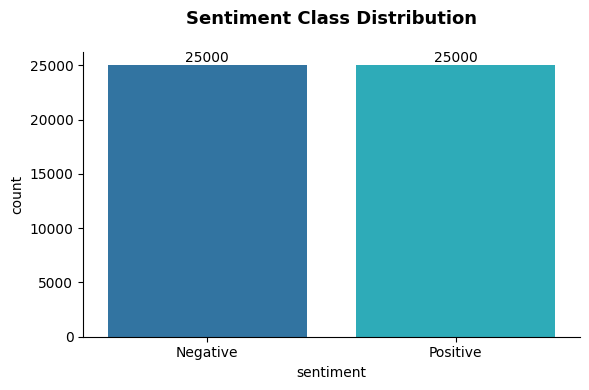

In [ ]:
# Create count plot
plt.figure(figsize=(6, 4))  # Set figure size
ax = sns.countplot(x='sentiment', data=data, palette=['#1f77b4', '#17becf'])

# Add title
plt.title('Sentiment Class Distribution', fontsize=13, weight='bold', ha='center', pad=20)

# Add counts above the bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

# Remove gridlines and figure border
plt.grid(False)
sns.despine()  # Remove figure border lines

# Set x-axis labels
ax.set_xticklabels(['Negative', 'Positive'], ha='center')

# Adjust y-axis settings
ax.tick_params(axis='y', labelsize=10)

# Display plot
plt.tight_layout()
plt.show()

#### **2.2.4 DISTRIBUTION OF REVIEW LENGTHS**

In [ ]:
data['word_count'] = data['review'].apply(lambda x: len(x.split()))
data['char_count'] = data['review'].apply(lambda x: len(x))


##### **BY WORDCOUNT**

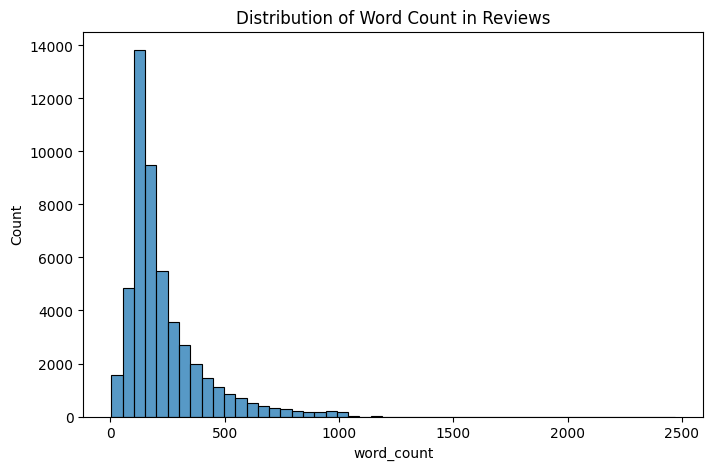

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['word_count'], bins=50)
plt.title("Distribution of Word Count in Reviews")
plt.show()


##### **BY SENTIMENT**

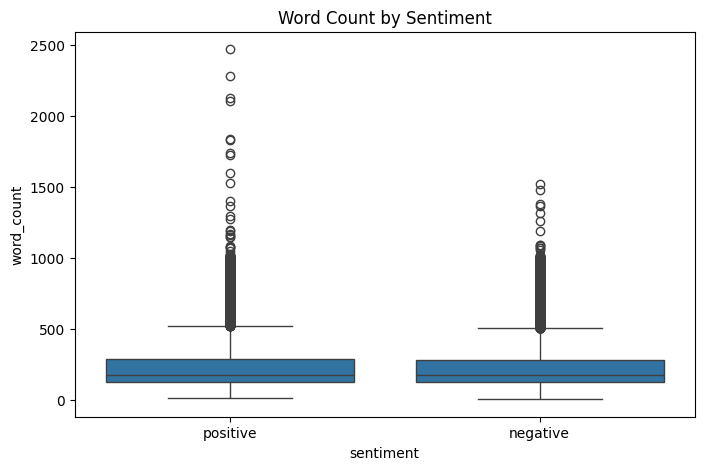

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sentiment', y='word_count', data=data)
plt.title("Word Count by Sentiment")
plt.show()


#### **2.2.5 CHECKING LONGEST AND SHORTEST REVIEWS**

In [ ]:
data.loc[data['word_count'].idxmax()]['review']


'Match 1: Tag Team Table Match Bubba Ray and Spike Dudley vs Eddie Guerrero and Chris Benoit Bubba Ray and Spike Dudley started things off with a Tag Team Table Match against Eddie Guerrero and Chris Benoit. According to the rules of the match, both opponents have to go through tables in order to get the win. Benoit and Guerrero heated up early on by taking turns hammering first Spike and then Bubba Ray. A German suplex by Benoit to Bubba took the wind out of the Dudley brother. Spike tried to help his brother, but the referee restrained him while Benoit and Guerrero ganged up on him in the corner. With Benoit stomping away on Bubba, Guerrero set up a table outside. Spike dashed into the ring and somersaulted over the top rope onto Guerrero on the outside! After recovering and taking care of Spike, Guerrero slipped a table into the ring and helped the Wolverine set it up. The tandem then set up for a double superplex from the middle rope which would have put Bubba through the table, bu

In [ ]:
data.loc[data['word_count'].idxmin()]['review']


'Primary plot!Primary direction!Poor interpretation.'

#### **2.2.6 WORDCLOUD BEFORE CLEANING**

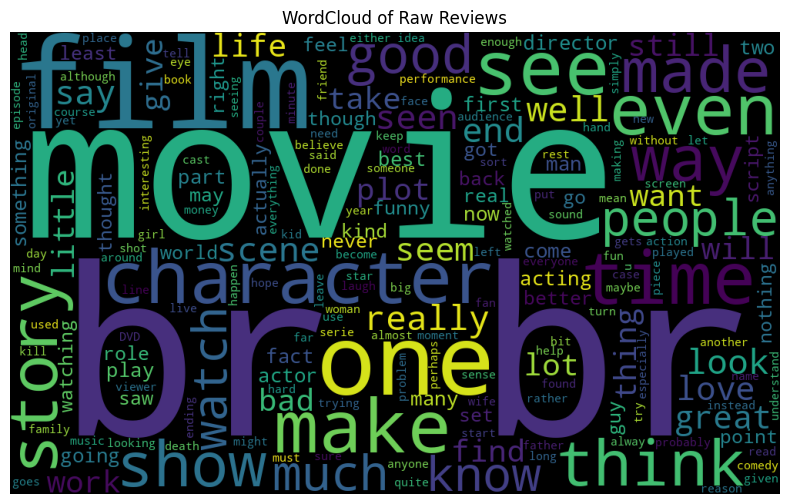

In [ ]:
from wordcloud import WordCloud

wc = WordCloud(width=1000, height=600).generate(" ".join(data['review']))

plt.figure(figsize=(12,6))
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud of Raw Reviews")
plt.show()


#### **DROP EXTRA COLUMNS OF EDA**

In [ ]:
cols_to_drop = ['word_count', 'char_count', 'tokens' , 'review_length', 'review_length_binned']

data = data.drop(columns=cols_to_drop, errors='ignore')
data.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## **3. TEXT PRE PROCESSING**

### **3.1 REMOVE CONTRACTIONS**

In [ ]:
data["contractions"] = data["review"].apply(lambda x: contractions.fix(x))
data["contractions"].head()


,contractions
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there is a family where a little boy...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


### **3.2 CONVERT TO LOWERCASE**

In [ ]:
data["lowercase"] = data["contractions"].str.lower()
data["lowercase"].head()

,lowercase
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...
2,i thought this was a wonderful way to spend ti...
3,basically there is a family where a little boy...
4,"petter mattei's ""love in the time of money"" is..."


### **3.3 REMOVE HTML TAGS**

In [ ]:
html_tags = re.compile(r'<.*?>')

data["no_htmltags"] = data["lowercase"].apply(lambda x: html_tags.sub(" ", x))
data["no_htmltags"].head()


,no_htmltags
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming t...
2,i thought this was a wonderful way to spend ti...
3,basically there is a family where a little boy...
4,"petter mattei's ""love in the time of money"" is..."


### **3.4 REMOVE URL**

In [ ]:
url_pattern = re.compile(r'http\S+|www\.\S+')

data["no_url"] = data["no_htmltags"].apply(lambda x: url_pattern.sub(" ", x))
data["no_url"].head()


,no_url
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming t...
2,i thought this was a wonderful way to spend ti...
3,basically there is a family where a little boy...
4,"petter mattei's ""love in the time of money"" is..."


### **3.5 REMOVE EMOJIS**

In [ ]:
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # flags
    "]+",
    flags=re.UNICODE
)

data["no_emoji"] = data["no_url"].apply(lambda x: emoji_pattern.sub(" ", x))
data["no_emoji"].head()


,no_emoji
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. the filming t...
2,i thought this was a wonderful way to spend ti...
3,basically there is a family where a little boy...
4,"petter mattei's ""love in the time of money"" is..."


#### **3.6 REMOVE PUNCTUATION**

In [ ]:
data["no_punct"] = data["no_emoji"].apply(
    lambda x: re.sub(r"[^a-zA-Z0-9\s]", " ", x)
)
data["no_punct"].head()


,no_punct
0,one of the other reviewers has mentioned that ...
1,a wonderful little production the filming t...
2,i thought this was a wonderful way to spend ti...
3,basically there is a family where a little boy...
4,petter mattei s love in the time of money is...


#### **3.7 TOKENIZATION**

In [ ]:
data["tokens"] = data["no_punct"].apply(word_tokenize)
data["tokens"].head()


,tokens
0,"[one, of, the, other, reviewers, has, mentione..."
1,"[a, wonderful, little, production, the, filmin..."
2,"[i, thought, this, was, a, wonderful, way, to,..."
3,"[basically, there, is, a, family, where, a, li..."
4,"[petter, mattei, s, love, in, the, time, of, m..."


#### **3.8 REMOVE STOPWORDS**

In [ ]:
stop_words = set(stopwords.words("english"))
negations = {"no", "not", "never", "n't"}
stop_words = stop_words - negations

data["no_stopwords"] = data["tokens"].apply(
    lambda x: [word for word in x if word not in stop_words]
)
data["no_stopwords"].head()


,no_stopwords
0,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,"[wonderful, little, production, filming, techn..."
2,"[thought, wonderful, way, spend, time, hot, su..."
3,"[basically, family, little, boy, jake, thinks,..."
4,"[petter, mattei, love, time, money, visually, ..."


### **3.9 POS BASED LEMMATIZATION**

In [ ]:
lemmatizer = WordNetLemmatizer()

def fast_lemmatize(tokens):
    cleaned = []
    for word in tokens:
        lemma = lemmatizer.lemmatize(word, pos='v')
        lemma = lemmatizer.lemmatize(lemma, pos='n')
        cleaned.append(lemma)
    return " ".join(cleaned)

data["lemmatized"] = data["no_stopwords"].apply(fast_lemmatize)
data["lemmatized"].head()


,lemmatized
0,one reviewer mention watch 1 oz episode hook r...
1,wonderful little production film technique una...
2,think wonderful way spend time hot summer week...
3,basically family little boy jake think zombie ...
4,petter mattei love time money visually stun fi...


#### **3.10 JOIN TOKENS BACK TO CLEANED TEXT**

In [ ]:
data["final_clean_text"] = data["lemmatized"].apply(lambda x: " ".join(x))
data["final_clean_text"].head()

,final_clean_text
0,o n e r e v i e w e r m e n t i o n w a ...
1,w o n d e r f u l l i t t l e p r o d u c ...
2,t h i n k w o n d e r f u l w a y s p e ...
3,b a s i c a l l y f a m i l y l i t t l e ...
4,p e t t e r m a t t e i l o v e t i m e ...


In [ ]:
data['sentiment'] = data['sentiment'].map({'positive': 1, 'negative': 0})
data['sentiment'].head()

,sentiment
0,1
1,1
2,1
3,0
4,1


## **4. FEATURE EXTRACTION**

In [ ]:
X = data['lemmatized']
y = data['sentiment']

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(X)

## **5. TEST-TRAIN SPLIT**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


In [ ]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 240816 stored elements and shape (2544, 24287)>

## **6. MODEL TRAINING**

In [ ]:
accuracy_scores = {}

### **6.1 LOGISTIC REGRESSION**

=== LOGISTIC REGRESSION ===

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.84      0.85       327
           1       0.83      0.86      0.85       309

    accuracy                           0.85       636
   macro avg       0.85      0.85      0.85       636
weighted avg       0.85      0.85      0.85       636


Confusion Matrix:

[[274  53]
 [ 44 265]]


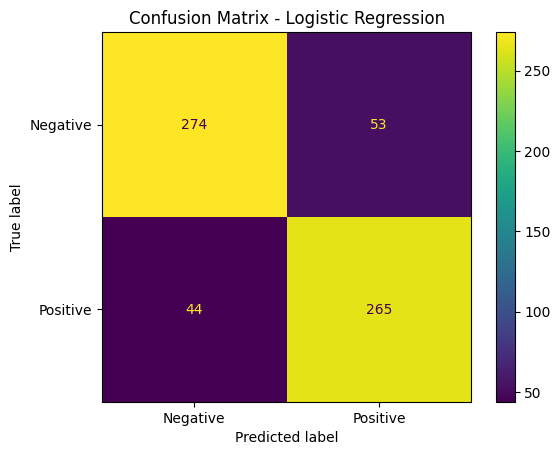

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

print("=== LOGISTIC REGRESSION ===")
print("\nClassification Report:\n")
print(classification_report(y_test, pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred_lr))

# Display the confusion matrix
cm_log_reg = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm_log_reg, display_labels=['Negative', 'Positive']).plot()
plt.title('Confusion Matrix - Logistic Regression')
plt.show()



In [ ]:
accuracy_scores['Logistic Regression'] = accuracy_score(y_test, pred_lr)

### **6.2 NAIVE BAYES**

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)

print("=== NAIVE BAYES ===")
print("\nClassification Report:\n")
print(classification_report(y_test, pred_nb))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred_nb))


=== NAIVE BAYES ===

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.88      0.86      4961
           1       0.87      0.85      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


Confusion Matrix:

[[4348  613]
 [ 770 4269]]


In [ ]:
accuracy_scores['Naive Bayes'] = accuracy_score(y_test, pred_nb)

### **6.3 LINEAR SVM**

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)

print("=== SUPPORT VECTOR MACHINE ===")
print("\nClassification Report:\n")
print(classification_report(y_test, pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, pred_svm))


=== SUPPORT VECTOR MACHINE ===

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.89      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


Confusion Matrix:

[[4379  582]
 [ 473 4566]]


In [ ]:
accuracy_scores['Linear SVM'] = accuracy_score(y_test, pred_svm)

### **XGBOOST**

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='mlogloss')
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

print("=== XGBOOST CLASSIFICATION REPORT ===")
print(classification_report(y_test, pred_xgb))

print("\n=== XGBOOST CONFUSION MATRIX ===")
print(confusion_matrix(y_test, pred_xgb))


=== XGBOOST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4961
           1       0.85      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


=== XGBOOST CONFUSION MATRIX ===
[[4192  769]
 [ 596 4443]]


In [ ]:
accuracy_scores['XGBoost'] = accuracy_score(y_test, pred_xgb)

## **7. ACCURACY SCORES**

In [ ]:
accuracy_scores

{'Logistic Regression': 0.8946,
 'Naive Bayes': 0.8617,
 'Linear SVM': 0.8945,
 'XGBoost': 0.8635}

In [ ]:

accuracy_df = pd.DataFrame(
    list(accuracy_scores.items()),
    columns=['Model', 'Accuracy']
)

print(accuracy_df)


                 Model  Accuracy
0  Logistic Regression    0.8946
1          Naive Bayes    0.8617
2           Linear SVM    0.8945
3              XGBoost    0.8635


## **8. COMPARISON OF ACCURACY SCORES OF ML MODELS**

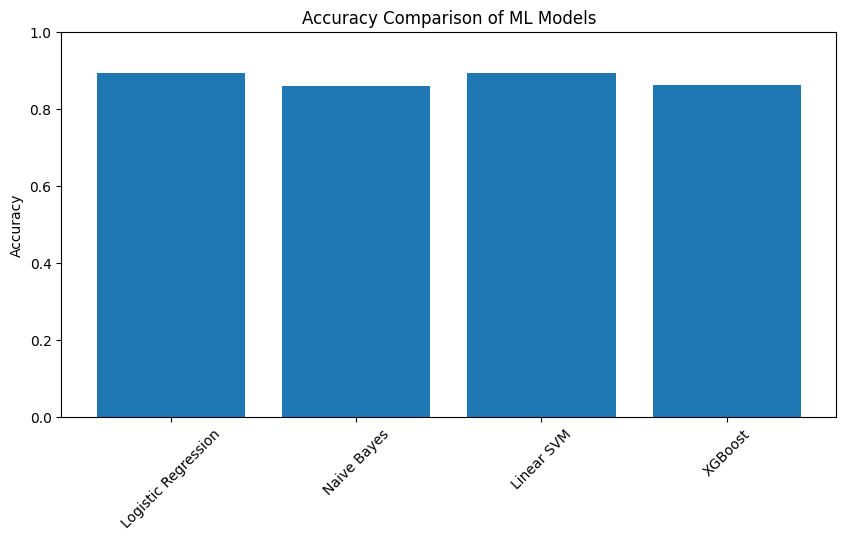

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'])
plt.title("Accuracy Comparison of ML Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()
